# Json structure

In [12]:
import json

data_path = 'data/COCO/test.json'
image_dir = 'data/PNG'

with open(data_path, "r") as f:
    coco_test = json.load(f)

print(f"Loaded JSON with keys: {list(coco_test.keys())}\n")

for key in coco_test:
    print(f"=== STRUCTURE OF '{key}' ===")

    value = coco_test[key]

    if isinstance(value, list):
        print(f"Type: List (Length: {len(value)})")
        if len(value) > 0:
            print("First item preview:")
            print(json.dumps(value[0], indent=4)) # Pretty print the first item only
        else:
            print("List is empty.")

    # Check if the value is a DICTIONARY (like 'info')
    elif isinstance(value, dict):
        print("Type: Dictionary")
        print(json.dumps(value, indent=4))
    
    # Check if it's just a simple string/number
    else:
        print(f"Type: Value -> {value}")
        
    print("-"*30)



Loaded JSON with keys: ['categories', 'images', 'annotations']

=== STRUCTURE OF 'categories' ===
Type: List (Length: 11)
First item preview:
{
    "supercategory": "Caption",
    "id": 1,
    "name": "Caption"
}
------------------------------
=== STRUCTURE OF 'images' ===
Type: List (Length: 4999)
First item preview:
{
    "id": 1,
    "width": 1025,
    "height": 1025,
    "file_name": "132a855ee8b23533d8ae69af0049c038171a06ddfcac892c3c6d7e6b4091c642.png",
    "collection": "ann_reports_00_04_fancy",
    "doc_name": "NASDAQ_FFIN_2002.pdf",
    "page_no": 9,
    "precedence": 0,
    "doc_category": "financial_reports"
}
------------------------------
=== STRUCTURE OF 'annotations' ===
Type: List (Length: 66531)
First item preview:
{
    "id": 8,
    "image_id": 1,
    "category_id": 1,
    "bbox": [
        210.06018382352943,
        31.14536268939389,
        173.9850743464052,
        39.270946654040586
    ],
    "segmentation": [
        [
            210.06018382352943,
        

# Categories Display

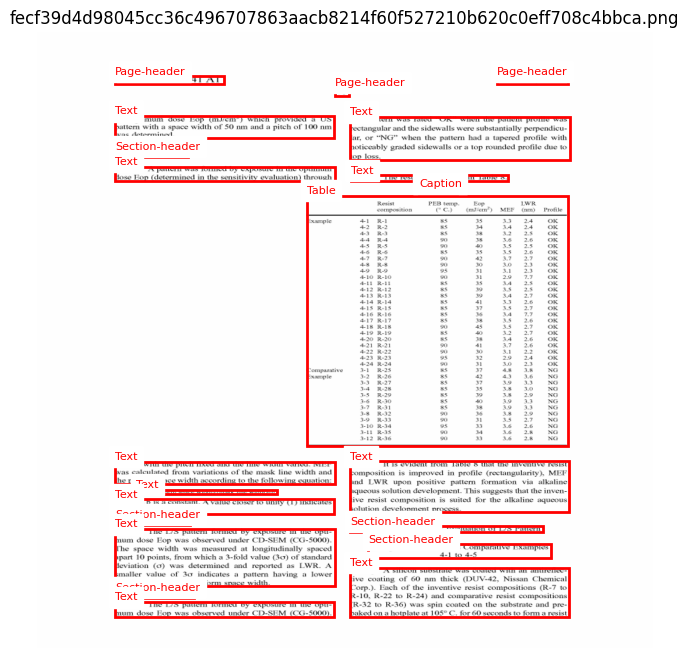

In [13]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---- paths ----
COCO_JSON = "data/COCO/val.json"
IMAGE_DIR = "data/PNG"

# list of png filenames you want to visualize
TARGET_IMAGES = {
    "fecf39d4d98045cc36c496707863aacb8214f60f527210b620c0eff708c4bbca.png"
}

# ---- load coco ----
with open(COCO_JSON, "r") as f:
    coco = json.load(f)

# build helper maps
image_by_id = {img["id"]: img for img in coco["images"]}
image_by_name = {img["file_name"]: img for img in coco["images"]}
category_by_id = {cat["id"]: cat["name"] for cat in coco["categories"]}

# group annotations by image_id
annotations_by_image = {}
for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

# ---- visualize ----
for fname in TARGET_IMAGES:
    if fname not in image_by_name:
        print(f"⚠️ {fname} not found in COCO images")
        continue

    img_info = image_by_name[fname]
    img_path = os.path.join(IMAGE_DIR, fname)

    image = Image.open(img_path).convert("RGB")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)
    ax.set_title(fname)
    ax.axis("off")

    for ann in annotations_by_image.get(img_info["id"], []):
        x, y, w, h = ann["bbox"]
        cat_name = category_by_id.get(ann["category_id"], "unknown")

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            x,
            y - 3,
            cat_name,
            color="red",
            fontsize=8,
            backgroundcolor="white"
        )

    plt.show()

# Run visulization for relationship mapping

In [17]:
import json
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# CONFIGURATION
# ==========================================
COCO_JSON = "data/COCO/test.json"
IMAGE_DIR = "data/PNG"
OUT_DIR = "test_folder_linked_debug"

CAT = {
    "Caption": 1,
    "Picture": 7,
    "Table": 9,
}

PARAMETER = 0.3
# ==========================================
# GEOMETRY HELPERS
# ==========================================
def bbox_center(b):
    return (b[0] + b[2] / 2, b[1] + b[3] / 2)

def edge_distance(fig_bbox, cap_bbox):
    fx, fy, fw, fh = fig_bbox
    cx, cy, cw, ch = cap_bbox

    cap_cx = cx + cw / 2
    cap_cy = cy + ch / 2

    left   = fx
    right  = fx + fw
    top    = fy
    bottom = fy + fh

    dx = max(left - cap_cx, 0, cap_cx - right)
    dy = max(top - cap_cy, 0, cap_cy - bottom)

    return math.hypot(dx, dy)

def get_layout_aware_cost(fig, cap):
    fb = fig["bbox"]
    dist = edge_distance(fb, cap["bbox"])
    norm_dist = dist / (PARAMETER * max(fb[2], fb[3]))
    return dist, norm_dist

# ==========================================
# MAIN
# ==========================================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    with open(COCO_JSON) as f:
        coco = json.load(f)

    image_map = {i["id"]: i for i in coco["images"]}
    cat_map = {c["id"]: c["name"] for c in coco["categories"]}

    anns_by_image = {}
    for a in coco["annotations"]:
        anns_by_image.setdefault(a["image_id"], []).append(a)

    for image_id, anns in anns_by_image.items():
        img_info = image_map[image_id]
        img_path = os.path.join(IMAGE_DIR, img_info["file_name"])

        if not os.path.exists(img_path):
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue

        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(image)
        ax.axis("off")

        figures = [a for a in anns if a["category_id"] in (CAT["Picture"], CAT["Table"])]
        captions = [a for a in anns if a["category_id"] == CAT["Caption"]]

        # Draw bounding boxes
        for a in anns:
            x, y, w, h = a["bbox"]
            cname = cat_map.get(a["category_id"], "Unknown")

            color = "gray"
            if cname == "Picture":
                color = "blue"
            elif cname == "Table":
                color = "green"
            elif cname == "Caption":
                color = "orange"

            ax.add_patch(
                patches.Rectangle(
                    (x, y), w, h,
                    fill=False, edgecolor=color, linewidth=1.5
                )
            )

        if figures and captions:
            # Compute all distances
            pairs = []
            for i, cap in enumerate(captions):
                for j, fig_ann in enumerate(figures):
                    rd, nd = get_layout_aware_cost(fig_ann, cap)
                    pairs.append((nd, rd, i, j))  # (norm_dist, real_dist, caption_idx, figure_idx)

            # Draw all possible links in gray
            for nd, rd, i, j in pairs:
                cx, cy = bbox_center(captions[i]["bbox"])
                fx, fy = bbox_center(figures[j]["bbox"])
                ax.plot([fx, cx], [fy, cy], color="gray", linewidth=1, alpha=0.3)
                mx, my = (fx + cx) / 2, (fy + cy) / 2
                ax.text(mx, my, f"{rd:.1f}/{nd:.2f}", color="white",
                        fontsize=6, fontweight="bold",
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))

            # -------------------------------
            # Greedy closest-per-caption, one-to-one assignment
            # -------------------------------
            pairs.sort()  # sort by normalized distance ascending
            assigned_figures = set()
            assigned_captions = set()
            final_links = []

            for nd, rd, i, j in pairs:
                if i in assigned_captions or j in assigned_figures:
                    continue
                assigned_captions.add(i)
                assigned_figures.add(j)
                final_links.append((i, j, rd, nd))

            # Draw final links in red
            max_norm = max(nd for _, _, _, nd in final_links) if final_links else 1.0
            for i, j, rd, nd in final_links:
                cx, cy = bbox_center(captions[i]["bbox"])
                fx, fy = bbox_center(figures[j]["bbox"])
                lw = 3.0 * (1 - nd / (max_norm + 1e-6))
                lw = max(lw, 0.5)
                ax.plot([fx, cx], [fy, cy], color="red", linewidth=lw, alpha=0.9)
                mx, my = (fx + cx) / 2, (fy + cy) / 2
                ax.text(mx, my - 10, f"{rd:.1f}/{nd:.2f}", color="yellow",
                        fontsize=7, fontweight="bold",
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))

        out_path = os.path.join(
            OUT_DIR,
            os.path.splitext(img_info["file_name"])[0] + "_linked_debug.png"
        )
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()


if __name__ == "__main__":
    main()


# Annotate relationships into train, test data

one json = one image = one graph

In [9]:
import json
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# CONFIGURATION
# ==========================================
COCO_JSON = "data/COCO/"
IMAGE_DIR = "data/PNG"
OUT_DIR = "data/"

CAT = {
    "Caption": 1,
    "Footnote": 2,
    "Formula": 3,
    "List-item": 4,
    "Page-footer": 5,
    "Page-header": 6,
    "Picture": 7,
    "Section-header": 8,
    "Table": 9,
    "Text": 10,
    "Title": 11
}

PARAMETER = 0.3
# ==========================================
# GEOMETRY HELPERS
# ==========================================
def bbox_center(b):
    return (b[0] + b[2] / 2, b[1] + b[3] / 2)

def edge_distance(fig_bbox, cap_bbox):
    fx, fy, fw, fh = fig_bbox
    cx, cy, cw, ch = cap_bbox

    cap_cx = cx + cw / 2
    cap_cy = cy + ch / 2

    left   = fx
    right  = fx + fw
    top    = fy
    bottom = fy + fh

    dx = max(left - cap_cx, 0, cap_cx - right)
    dy = max(top - cap_cy, 0, cap_cy - bottom)

    return math.hypot(dx, dy)

def get_layout_aware_cost(fig, cap):
    fb = fig["bbox"]
    dist = edge_distance(fb, cap["bbox"])
    norm_dist = dist / (PARAMETER * max(fb[2], fb[3]))
    return dist, norm_dist

# ==========================================
# MAIN
# ==========================================
def main():
    for part in ["train", "val", "test"]:
        os.makedirs(OUT_DIR + part + "_data", exist_ok=True)
    
        with open(COCO_JSON + part + ".json") as f:
            coco = json.load(f)
    
        image_map = {i["id"]: i for i in coco["images"]}
        cat_map = {c["id"]: c["name"] for c in coco["categories"]}
    
        anns_by_image = {}
        for a in coco["annotations"]:
            anns_by_image.setdefault(a["image_id"], []).append(a)
    
        for image_id, anns in anns_by_image.items():
            img_info = image_map[image_id]
            img_path = os.path.join(IMAGE_DIR, img_info["file_name"])
    
            if not os.path.exists(img_path):
                continue
    
            try:
                image = Image.open(img_path).convert("RGB")
            except:
                continue
    
            nodes = []
    
            for a in anns:
                nodes.append({
                    "node_id": a["id"],
                    "category_id": a["category_id"],
                    "category_name": cat_map[a["category_id"]],
                    "bbox": a["bbox"]
                })
    
            
            captions = [a for a in anns if a["category_id"] == CAT["Caption"]]
            
            # --- Link targets ---
            link_targets = [
                a for a in anns
                if a["category_id"] in (
                    CAT["Table"],
                    CAT["Picture"],
                    CAT["Formula"]
                )
            ]
            final_links = []
    
            if link_targets and captions:
                # Compute all distances
                pairs = []
                for i, cap in enumerate(captions):
                    for j, fig_ann in enumerate(link_targets):
                        rd, nd = get_layout_aware_cost(fig_ann, cap)
                        pairs.append((nd, rd, i, j))  # (norm_dist, real_dist, caption_idx, figure_idx)
    
                # -------------------------------
                # Greedy closest-per-caption, one-to-one assignment
                # -------------------------------
                pairs.sort()  # sort by normalized distance ascending
                assigned_link_targets = set()
                assigned_captions = set()
                
    
                for nd, rd, i, j in pairs:
                    if i in assigned_captions or j in assigned_link_targets:
                        continue
                    assigned_captions.add(i)
                    assigned_link_targets.add(j)
                    final_links.append((i, j, rd, nd))
    
            edges = []
    
            # initialize all possible caption → target edges as negative
            for cap in captions:
                for tgt in link_targets:
                    edges.append({
                        "from": cap["id"],
                        "to": tgt["id"],
                        "label": 0,
                        "distance": None,
                        "norm_distance": None
                    })
    
            # mark positive edges from heuristic matching
            for i, j, rd, nd in final_links:
                cap_id = captions[i]["id"]
                tgt_id = link_targets[j]["id"]
    
                for e in edges:
                    if e["from"] == cap_id and e["to"] == tgt_id:
                        e["label"] = 1
                        e["distance"] = rd
                        e["norm_distance"] = nd
                        break
    
            # ==========================
            # BUILD GRAPH JSON
            # ==========================
            graph = {
                "image_id": image_id,
                "file_name": img_info["file_name"],
                "width": img_info["width"],
                "height": img_info["height"],
                "nodes": nodes,
                "edges": edges
            }
    
            # ==========================
            # SAVE
            # ==========================
            out_path = os.path.join(
                OUT_DIR + part + "_data",
                f"graph_{image_id:06d}.json"
            )
    
            with open(out_path, "w") as f:
                json.dump(graph, f, indent=2)
           


if __name__ == "__main__":
    main()


In [10]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================
# CONFIG
# ==========================
GRAPH_DIR = "data/train_data"
IMAGE_DIR = "data/PNG"
OUT_DIR = "graph_visual_debug_train"
MAX_FILES = 10

# farby pre kategórie
COLORS = {
    "Caption": "orange",
    "Table": "green",
    "Picture": "blue",
    "Formula": "purple",
    "Text": "gray",
    "Title": "red",
    "Section-header": "brown",
    "List-item": "cyan",
    "Footnote": "pink",
    "Page-header": "yellow",
    "Page-footer": "yellow"
}

# ==========================
def bbox_center(b):
    return b[0] + b[2] / 2, b[1] + b[3] / 2

# ==========================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    files = sorted([
        f for f in os.listdir(GRAPH_DIR)
        if f.startswith("graph_") and f.endswith(".json")
    ])[:MAX_FILES]

    print(f"Visualizing {len(files)} graphs...")

    for fname in files:
        graph_path = os.path.join(GRAPH_DIR, fname)

        with open(graph_path) as f:
            graph = json.load(f)

        img_path = os.path.join(IMAGE_DIR, graph["file_name"])
        if not os.path.exists(img_path):
            print(f"Image missing: {img_path}")
            continue

        image = Image.open(img_path).convert("RGB")

        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(image)
        ax.axis("off")

        # ------------------
        # Draw nodes
        # ------------------
        node_map = {}
        for n in graph["nodes"]:
            node_map[n["node_id"]] = n
            x, y, w, h = n["bbox"]
            color = COLORS.get(n["category_name"], "white")

            ax.add_patch(
                patches.Rectangle(
                    (x, y), w, h,
                    fill=False,
                    edgecolor=color,
                    linewidth=1.5
                )
            )

            ax.text(
                x,
                y - 2,
                n["category_name"],
                fontsize=6,
                color=color,
                backgroundcolor="black"
            )

        # ------------------
        # Draw positive edges
        # ------------------
        for e in graph["edges"]:
            if e["label"] != 1:
                continue

            src = node_map[e["from"]]
            tgt = node_map[e["to"]]

            sx, sy = bbox_center(src["bbox"])
            tx, ty = bbox_center(tgt["bbox"])

            ax.plot(
                [sx, tx],
                [sy, ty],
                color="red",
                linewidth=2.5,
                alpha=0.9
            )

            mx, my = (sx + tx) / 2, (sy + ty) / 2
            ax.text(
                mx,
                my,
                f"{e['norm_distance']:.2f}",
                fontsize=7,
                color="yellow",
                backgroundcolor="black"
            )

        # ------------------
        # Save
        # ------------------
        out_path = os.path.join(
            OUT_DIR,
            fname.replace(".json", ".png")
        )
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()

        print(f"Saved: {out_path}")

    print("DONE.")

# ==========================
if __name__ == "__main__":
    main()


Visualizing 10 graphs...
Saved: graph_visual_debug_train\graph_000000.png
Saved: graph_visual_debug_train\graph_000001.png
Saved: graph_visual_debug_train\graph_000002.png
Saved: graph_visual_debug_train\graph_000003.png
Saved: graph_visual_debug_train\graph_000004.png
Saved: graph_visual_debug_train\graph_000005.png
Saved: graph_visual_debug_train\graph_000006.png
Saved: graph_visual_debug_train\graph_000007.png
Saved: graph_visual_debug_train\graph_000008.png
Saved: graph_visual_debug_train\graph_000009.png
DONE.
